<a href="https://colab.research.google.com/github/sergioalejandromanriquerubiose-ui/PROGRAMACION/blob/main/Bancolombia_Analisis_Colab_concambios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis de Utilidad de Bancolombia (2005 – Presente)
**Instrucciones rápidas:**
1. Ejecuta las celdas **en orden** (Shift + Enter)
2. En la celda de "Carga de datos", sube tu archivo Excel cuando aparezca el botón
3. Si no tienes Excel, el programa usa datos de muestra automáticamente


In [ ]:
# ============================================================
# CELDA 1 — Instalación de dependencias
# ============================================================
# Colab ya trae pandas, numpy y matplotlib. Solo necesitamos openpyxl y requests.
!pip install openpyxl requests -q
print("✓ Dependencias listas")


✓ Dependencias listas


In [ ]:
# ============================================================
# CELDA 2 — Importaciones
# ============================================================
import os
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from datetime import datetime
from IPython.display import display, HTML

print("✓ Librerías importadas correctamente")


✓ Librerías importadas correctamente


In [ ]:
# ============================================================
# CELDA 3 — Módulo: DataLoader
# ============================================================

class DataLoader:
    """
    Carga y limpia datos de utilidad desde un archivo Excel.
    Si no se sube ningún archivo, lanza un error solicitando el archivo real.
    """

    def __init__(self, filepath: str = None):
        self.filepath = filepath

    def load_from_bytes(self, file_bytes: bytes) -> pd.DataFrame:
        """Lee un Excel subido desde Colab (como bytes)."""
        df = pd.read_excel(io.BytesIO(file_bytes))
        return self._clean(df)

    def load_from_path(self, path: str) -> pd.DataFrame | None:
        """Lee un Excel desde ruta de disco."""
        if not os.path.exists(path):
            return None
        try:
            return self._clean(pd.read_excel(path))
        except Exception as e:
            print(f"  Error leyendo Excel: {e}")
            return None

    def _clean(self, df: pd.DataFrame) -> pd.DataFrame:
        """Estandariza nombres de columnas y tipos de datos."""
        df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

        # Detectar columna de año y utilidad automáticamente
        year_col = next((c for c in df.columns if "a" in c and ("o" in c or "ñ" in c)), df.columns[0])
        util_col = next((c for c in df.columns if any(k in c for k in ["util", "ganancia", "profit", "neta"])), df.columns[1])

        df = df.rename(columns={year_col: "año", util_col: "utilidad_neta_mm"})
        df["año"] = pd.to_numeric(df["año"], errors="coerce").astype("Int64")
        df["utilidad_neta_mm"] = pd.to_numeric(df["utilidad_neta_mm"], errors="coerce")

        # Filtrar años válidos con list comprehension
        valid_years = [y for y in df["año"] if pd.notna(y) and 2000 <= int(y) <= 2030]
        df = df[df["año"].isin(valid_years)].dropna(subset=["utilidad_neta_mm"])
        return df[["año", "utilidad_neta_mm"]].sort_values("año").reset_index(drop=True)

    def generate_sample_data(self) -> pd.DataFrame:
        """Lanza un error indicando que se debe subir un archivo Excel real."""
        raise FileNotFoundError(
            "No se encontró ningún archivo Excel. "
            "Por favor sube tu archivo con las columnas: año | utilidad_neta_mm"
        )

print("✓ Clase DataLoader definida")


✓ Clase DataLoader definida


In [ ]:
# ============================================================
# CELDA 4 — Módulo: BancolombiaAPIFetcher
# ============================================================

class BancolombiaAPIFetcher:
    """
    Obtiene precios históricos de la acción de Bancolombia
    desde Yahoo Finance (ticker CIB en NYSE). No requiere API key.
    """

    BASE_URL = "https://query2.finance.yahoo.com/v8/finance/chart/{ticker}"
    TICKER   = "CIB"
    HEADERS  = {"User-Agent": "Mozilla/5.0"}

    def fetch_stock_data(self) -> pd.DataFrame | None:
        """Descarga precios mensuales de los últimos 20 años y los agrupa por año."""
        url    = self.BASE_URL.format(ticker=self.TICKER)
        params = {"interval": "1mo", "range": "20y"}

        try:
            r = requests.get(url, params=params, headers=self.HEADERS, timeout=10)
            r.raise_for_status()
            return self._parse(r.json())
        except Exception as e:
            print(f"  ⚠ API no disponible ({type(e).__name__}). Se omiten datos de precio.")
            return None

    def _parse(self, data: dict) -> pd.DataFrame | None:
        try:
            result     = data["chart"]["result"][0]
            timestamps = result["timestamp"]
            closes     = result["indicators"]["quote"][0]["close"]
            volumes    = result["indicators"]["quote"][0]["volume"]

            # List comprehension para construir registros limpios
            records = [
                {
                    "fecha":              pd.Timestamp(ts, unit="s"),
                    "precio_cierre_usd":  round(float(c), 2) if c else np.nan,
                    "volumen":            int(v) if v else 0,
                }
                for ts, c, v in zip(timestamps, closes, volumes)
                if c is not None
            ]

            df = pd.DataFrame(records)
            df["año"] = df["fecha"].dt.year

            return (
                df.groupby("año")
                .agg(precio_promedio_usd=("precio_cierre_usd", "mean"),
                     volumen_total=("volumen", "sum"))
                .reset_index()
                .assign(precio_promedio_usd=lambda x: x["precio_promedio_usd"].round(2))
            )
        except Exception as e:
            print(f"  ⚠ Error parseando API: {e}")
            return None

print("✓ Clase BancolombiaAPIFetcher definida")


✓ Clase BancolombiaAPIFetcher definida


In [ ]:
# ============================================================
# CELDA 5 — Módulo: UtilityAnalyzer
# ============================================================

class UtilityAnalyzer:
    """
    Calcula métricas financieras sobre la utilidad neta:
    crecimiento YoY, media móvil, índice base 100, z-score y CAGR.
    Usa numpy para todos los cálculos numéricos.
    """

    def __init__(self, df_local: pd.DataFrame, df_api: pd.DataFrame = None):
        self.df_api = df_api
        self.df     = self._merge(df_local, df_api)

    def _merge(self, df_local, df_api):
        if df_api is not None and not df_api.empty:
            return pd.merge(df_local, df_api, on="año", how="left")
        return df_local.copy()

    def run_full_analysis(self) -> dict:
        """Ejecuta todos los cálculos y retorna métricas de resumen."""
        self._add_growth()
        self._add_moving_average()
        self._add_base100()
        self._add_zscore()
        return self._summary()

    def _add_growth(self):
        vals = self.df["utilidad_neta_mm"].to_numpy(dtype=float)
        # List comprehension para crecimiento YoY
        self.df["crecimiento_pct"] = [
            round(((vals[i] - vals[i-1]) / vals[i-1]) * 100, 2)
            if i > 0 and vals[i-1] != 0 else np.nan
            for i in range(len(vals))
        ]

    def _add_moving_average(self, window=3):
        vals   = self.df["utilidad_neta_mm"].to_numpy(dtype=float)
        kernel = np.ones(window) / window
        ma     = np.convolve(vals, kernel, mode="full")[:len(vals)]
        ma[:window - 1] = np.nan
        self.df[f"media_movil_{window}a"] = np.round(ma, 1)

    def _add_base100(self):
        base = self.df["utilidad_neta_mm"].iloc[0]
        self.df["indice_base100"] = np.round((self.df["utilidad_neta_mm"] / base) * 100, 2)

    def _add_zscore(self):
        vals = self.df["utilidad_neta_mm"].to_numpy(dtype=float)
        self.df["zscore"] = np.round((vals - np.nanmean(vals)) / np.nanstd(vals), 3)

    def _summary(self) -> dict:
        vals    = self.df["utilidad_neta_mm"].to_numpy(dtype=float)
        n       = len(vals) - 1
        cagr    = ((vals[-1] / vals[0]) ** (1/n) - 1) * 100 if n > 0 and vals[0] > 0 else 0.0

        falling = [int(self.df["año"].iloc[i]) for i in range(1, len(self.df)) if vals[i] < vals[i-1]]

        return {
            "cagr":             round(float(cagr), 2),
            "mean":             round(float(np.nanmean(vals)), 1),
            "median":           round(float(np.nanmedian(vals)), 1),
            "std":              round(float(np.nanstd(vals)), 1),
            "best_year":        int(self.df.loc[self.df["utilidad_neta_mm"].idxmax(), "año"]),
            "best_value":       round(float(self.df["utilidad_neta_mm"].max()), 1),
            "worst_year":       int(self.df.loc[self.df["utilidad_neta_mm"].idxmin(), "año"]),
            "worst_value":      round(float(self.df["utilidad_neta_mm"].min()), 1),
            "falling_years":    falling,
            "total_growth_pct": round(((vals[-1] - vals[0]) / vals[0]) * 100, 2),
            "first_year":       int(self.df["año"].iloc[0]),
            "last_year":        int(self.df["año"].iloc[-1]),
            "total_years":      len(self.df),
        }

    @staticmethod
    def validate_dataframe(df: pd.DataFrame) -> bool:
        missing = {"año", "utilidad_neta_mm"} - set(df.columns)
        if missing:
            print(f"  ✗ Columnas faltantes: {missing}")
            return False
        return not df.empty

print("✓ Clase UtilityAnalyzer definida")


✓ Clase UtilityAnalyzer definida


In [ ]:
# ============================================================
# CELDA 6 — Módulo: FinancialVisualizer
# ============================================================

COLORS = {
    "amarillo": "#F5C518", "azul": "#003087", "gris": "#5A5A5A",
    "verde": "#2ECC71",    "rojo": "#E74C3C", "fondo": "#F9F9F9",
    "linea": "#CCCCCC",
}

class FinancialVisualizer:
    """Genera las 4 visualizaciones del análisis con matplotlib."""

    def __init__(self, df: pd.DataFrame):
        self.df = df
        plt.rcParams.update({
            "font.family": "DejaVu Sans", "axes.facecolor": COLORS["fondo"],
            "figure.facecolor": "white",  "axes.grid": True,
            "grid.color": COLORS["linea"],"grid.linewidth": 0.7,
            "axes.spines.top": False,     "axes.spines.right": False,
        })

    def plot_all(self):
        """Genera y muestra todas las gráficas."""
        self.plot_utilidad_historica()
        self.plot_crecimiento_yoy()
        self.plot_dashboard()
        if "precio_promedio_usd" in self.df.columns:
            self.plot_precio_vs_utilidad()

    def plot_utilidad_historica(self):
        fig, ax = plt.subplots(figsize=(14, 6))
        años  = self.df["año"].astype(str).tolist()
        vals  = self.df["utilidad_neta_mm"].tolist()

        # List comprehension para colores de barras
        colors = [COLORS["verde"] if i == 0 or vals[i] >= vals[i-1] else COLORS["rojo"]
                  for i in range(len(vals))]

        bars = ax.bar(años, vals, color=colors, edgecolor="white", linewidth=0.5)

        # Media móvil
        col_ma = [c for c in self.df.columns if "media_movil" in c]
        if col_ma:
            ax.plot(años, self.df[col_ma[0]], color=COLORS["azul"],
                    linewidth=2.5, marker="o", markersize=4, label="Media móvil 3 años")
            ax.legend(fontsize=9)

        # Etiquetas sobre barras
        labels = [f"{v/1000:.1f}B" if v >= 1000 else f"{v:.0f}" for v in vals]
        for bar, label in zip(bars, labels):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                    label, ha="center", va="bottom", fontsize=7.5, color=COLORS["gris"])

        ax.set_title("Utilidad Neta Histórica de Bancolombia\n(Miles de millones COP)",
                     fontsize=14, fontweight="bold", color=COLORS["azul"], pad=15)
        ax.set_xlabel("Año"); ax.set_ylabel("Utilidad Neta (Miles de MM COP)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout(); plt.show()

    def plot_crecimiento_yoy(self):
        if "crecimiento_pct" not in self.df.columns: return
        df  = self.df.dropna(subset=["crecimiento_pct"])
        fig, ax = plt.subplots(figsize=(14, 5))
        años = df["año"].astype(str).tolist()
        crec = df["crecimiento_pct"].tolist()
        colors = [COLORS["verde"] if v >= 0 else COLORS["rojo"] for v in crec]
        ax.bar(años, crec, color=colors, edgecolor="white")
        ax.axhline(0, color=COLORS["azul"], linewidth=1.2, linestyle="--")
        avg = np.nanmean(crec)
        ax.axhline(avg, color=COLORS["amarillo"], linewidth=2, label=f"Promedio: {avg:.1f}%")
        ax.legend(fontsize=9)
        ax.set_title("Crecimiento Interanual (YoY) de la Utilidad Neta",
                     fontsize=13, fontweight="bold", color=COLORS["azul"])
        ax.set_xlabel("Año"); ax.set_ylabel("Variación (%)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout(); plt.show()

    def plot_dashboard(self):
        fig = plt.figure(figsize=(16, 10))
        fig.suptitle("Dashboard · Análisis Bancolombia", fontsize=16,
                     fontweight="bold", color=COLORS["azul"])
        gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

        # Panel A: Índice base 100
        ax1 = fig.add_subplot(gs[0, 0])
        if "indice_base100" in self.df.columns:
            ax1.plot(self.df["año"], self.df["indice_base100"],
                     color=COLORS["azul"], linewidth=2.5, marker="o", markersize=4)
            ax1.fill_between(self.df["año"], self.df["indice_base100"], 100,
                             alpha=0.15, color=COLORS["azul"])
            ax1.axhline(100, linestyle="--", color="gray", linewidth=1)
            ax1.set_title("Índice Base 100", fontsize=10, fontweight="bold")
            ax1.set_ylabel("Índice")

        # Panel B: Histograma
        ax2 = fig.add_subplot(gs[0, 1])
        vals = self.df["utilidad_neta_mm"].dropna().tolist()
        ax2.hist(vals, bins=8, color=COLORS["amarillo"], edgecolor=COLORS["azul"], linewidth=1.2)
        ax2.axvline(np.mean(vals), color=COLORS["rojo"], linestyle="--",
                    linewidth=1.5, label=f"Media: {np.mean(vals):,.0f}")
        ax2.legend(fontsize=8)
        ax2.set_title("Distribución de la Utilidad", fontsize=10, fontweight="bold")
        ax2.set_xlabel("Miles de MM COP")

        # Panel C: Z-score
        ax3 = fig.add_subplot(gs[1, 0])
        if "zscore" in self.df.columns:
            z = self.df["zscore"].tolist()
            años = self.df["año"].tolist()
            z_colors = [COLORS["rojo"] if abs(v) > 2 else COLORS["verde"] if v > 0
                        else COLORS["gris"] for v in z]
            ax3.bar(años, z, color=z_colors, edgecolor="white")
            ax3.axhline(2,  linestyle="--", color="red", linewidth=1, alpha=0.6)
            ax3.axhline(-2, linestyle="--", color="red", linewidth=1, alpha=0.6)
            ax3.set_title("Z-Score (Años Atípicos)", fontsize=10, fontweight="bold")
            ax3.set_ylabel("Z-Score"); ax3.set_xlabel("Año")

        # Panel D: Crecimiento acumulado
        ax4 = fig.add_subplot(gs[1, 1])
        cumul = self.df["utilidad_neta_mm"].pct_change().add(1).cumprod().subtract(1).multiply(100)
        ax4.plot(self.df["año"], cumul, color=COLORS["verde"], linewidth=2.5)
        ax4.fill_between(self.df["año"], cumul, 0, alpha=0.15, color=COLORS["verde"])
        ax4.set_title("Crecimiento Acumulado (%)", fontsize=10, fontweight="bold")
        ax4.set_ylabel("Crecimiento %")
        ax4.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax4.set_xlabel("Año")

        plt.tight_layout(); plt.show()

    def plot_precio_vs_utilidad(self):
        df = self.df.dropna(subset=["precio_promedio_usd"])
        if df.empty: return
        fig, ax1 = plt.subplots(figsize=(14, 6))
        ax2 = ax1.twinx()
        ax1.bar(df["año"], df["utilidad_neta_mm"], color=COLORS["amarillo"],
                alpha=0.7, label="Utilidad Neta (MM COP)")
        ax2.plot(df["año"], df["precio_promedio_usd"], color=COLORS["azul"],
                 linewidth=2.5, marker="o", markersize=5, label="Precio CIB (USD)")
        ax1.set_ylabel("Utilidad Neta (Miles de MM COP)"); ax2.set_ylabel("Precio (USD)")
        ax1.set_xlabel("Año")
        ax1.set_title("Utilidad Neta vs. Precio de Acción (CIB - NYSE)",
                      fontsize=13, fontweight="bold", color=COLORS["azul"])
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
        plt.tight_layout(); plt.show()

print("✓ Clase FinancialVisualizer definida")


✓ Clase FinancialVisualizer definida


In [ ]:
# ============================================================
# CELDA 7 — Módulo: ReportGenerator
# ============================================================

class ReportGenerator:
    """Genera el reporte de texto con métricas y tabla histórica."""

    def __init__(self, df: pd.DataFrame, results: dict):
        self.df      = df
        self.results = results

    def build_report(self) -> str:
        r   = self.results
        now = datetime.now().strftime("%Y-%m-%d %H:%M")
        lines = [
            "=" * 62,
            "  REPORTE DE ANÁLISIS FINANCIERO",
            "  Bancolombia S.A. – Utilidad Neta Histórica",
            f"  Generado: {now}",
            "=" * 62,
            "",
            f"  Período:  {r['first_year']} – {r['last_year']}  ({r['total_years']} años)",
            "",
            "  MÉTRICAS CLAVE",
            f"  ├─ CAGR:                {r['cagr']:.2f}%",
            f"  ├─ Crecimiento total:   {r['total_growth_pct']:.1f}%",
            f"  ├─ Promedio anual:  COP {r['mean']:>12,.1f} MM",
            f"  ├─ Mediana:         COP {r['median']:>12,.1f} MM",
            f"  └─ Desv. estándar:  COP {r['std']:>12,.1f} MM",
            "",
            f"  Mejor año: {r['best_year']}  → COP {r['best_value']:>10,.1f} MM",
            f"  Peor año:  {r['worst_year']}  → COP {r['worst_value']:>10,.1f} MM",
            "",
        ]

        if r["falling_years"]:
            lines += ["  Años con caída: " + ", ".join(str(y) for y in r["falling_years"]), ""]

        lines += [
            "  TABLA HISTÓRICA",
            "  " + "-" * 56,
            "  {:>6}  {:>14}  {:>11}  {:>9}".format("AÑO", "UTILIDAD (MM)", "CREC. YOY", "Z-SCORE"),
            "  " + "-" * 56,
        ]

        # List comprehension para filas de la tabla
        rows = [
            "  {:>6}  {:>14,.1f}  {:>10}  {:>9}".format(
                int(row["año"]),
                row["utilidad_neta_mm"],
                f"{row['crecimiento_pct']:+.1f}%" if pd.notna(row.get("crecimiento_pct")) else "N/A",
                f"{row['zscore']:+.3f}"            if pd.notna(row.get("zscore"))           else "N/A",
            )
            for _, row in self.df.iterrows()
        ]
        lines += rows + ["  " + "-" * 56, ""]

        cagr = r["cagr"]
        lines += ["  INTERPRETACIÓN", "  " + "-" * 56]
        if cagr > 10:
            lines.append(f"  ✓ Crecimiento SÓLIDO: CAGR {cagr:.1f}% — supera el promedio del sector.")
        elif cagr > 5:
            lines.append(f"  ~ Crecimiento MODERADO: CAGR {cagr:.1f}%.")
        else:
            lines.append(f"  ⚠ Crecimiento BAJO: CAGR {cagr:.1f}%.")

        if "zscore" in self.df.columns:
            anomalies = [(int(r2["año"]), round(r2["zscore"], 2))
                         for _, r2 in self.df.iterrows()
                         if pd.notna(r2["zscore"]) and abs(r2["zscore"]) > 2]
            if anomalies:
                lines.append("  ⚠ Años atípicos (|z|>2): " +
                              ", ".join(f"{y} (z={z})" for y, z in anomalies))

        lines += ["", "=" * 62, "  FIN DEL REPORTE", "=" * 62]
        return "\n".join(lines)

    def print_report(self):
        print(self.build_report())

    def save_report(self, filename="reporte_bancolombia.txt"):
        """Guarda el reporte y lo ofrece como descarga en Colab."""
        with open(filename, "w", encoding="utf-8") as f:
            f.write(self.build_report())
        from google.colab import files
        files.download(filename)
        print(f"✓ Reporte guardado y descargado: {filename}")

print("✓ Clase ReportGenerator definida")


✓ Clase ReportGenerator definida


In [ ]:
# ============================================================
# CELDA 8 — Carga de datos
# ============================================================
# Se requiere un archivo Excel con las columnas: año | utilidad_neta_mm

from google.colab import files as colab_files

loader    = DataLoader()
df_local  = None

print("Selecciona tu archivo Excel (.xlsx) con los datos de Bancolombia.")
print("Columnas requeridas: año | utilidad_neta_mm\n")

uploaded = colab_files.upload()
if not uploaded:
    raise FileNotFoundError("No se subió ningún archivo. Sube tu Excel para continuar.")

filename = list(uploaded.keys())[0]
df_local = loader.load_from_bytes(uploaded[filename])
print(f"\n✓ Archivo '{filename}' cargado: {len(df_local)} registros.")

display(df_local.head(5))


Selecciona tu archivo Excel (.xlsx) con los datos de Bancolombia.
Columnas requeridas: año | utilidad_neta_mm



Saving Base de datos BancolombiaZZZ.xlsx to Base de datos BancolombiaZZZ.xlsx

✓ Archivo 'Base de datos BancolombiaZZZ.xlsx' cargado: 20 registros.


,año,utilidad_neta_mm
0,2005,946.9
1,2006,749.5
2,2007,1086.9
3,2008,1290.6
4,2009,1257.0


In [ ]:
# ============================================================
# CELDA 9 — Consulta API (Yahoo Finance – CIB)
# ============================================================
fetcher = BancolombiaAPIFetcher()
df_api  = fetcher.fetch_stock_data()

if df_api is not None:
    print(f"✓ {len(df_api)} registros de precio obtenidos de la API.")
    display(df_api.head())
else:
    print("⚠ Sin datos de API. Se continúa con datos locales.")


✓ 21 registros de precio obtenidos de la API.


,año,precio_promedio_usd,volumen_total
0,2006,28.44,65573100
1,2007,31.99,132346700
2,2008,30.90,135147700
3,2009,31.51,111006800
4,2010,54.95,92780500


In [ ]:
# ============================================================
# CELDA 10 — Análisis financiero
# ============================================================
analyzer = UtilityAnalyzer(df_local, df_api)
results  = analyzer.run_full_analysis()

print(f"✓ CAGR:           {results['cagr']:.2f}%")
print(f"✓ Mejor año:      {results['best_year']}  →  COP {results['best_value']:,.0f} MM")
print(f"✓ Peor año:       {results['worst_year']}  →  COP {results['worst_value']:,.0f} MM")
print(f"✓ Promedio anual: COP {results['mean']:,.0f} MM")
print(f"✓ Crecimiento total del período: {results['total_growth_pct']:.1f}%")
print()
display(analyzer.df)


✓ CAGR:           10.46%
✓ Mejor año:      2022  →  COP 7,053 MM
✓ Peor año:       2020  →  COP 287 MM
✓ Promedio anual: COP 2,564 MM
✓ Crecimiento total del período: 561.9%



,año,utilidad_neta_mm,precio_promedio_usd,volumen_total,crecimiento_pct,media_movil_3a,indice_base100,zscore
0,2005,946.9,NaN,NaN,NaN,NaN,100.00,-0.860
1,2006,749.5,28.44,65573100.0,-20.85,NaN,79.15,-0.965
2,2007,1086.9,31.99,132346700.0,45.02,927.8,114.79,-0.785
3,2008,1290.6,30.90,135147700.0,18.74,1042.3,136.30,-0.677
4,2009,1257.0,31.51,111006800.0,-2.60,1211.5,132.75,-0.695
5,2010,1436.0,54.95,92780500.0,14.24,1327.9,151.65,-0.600
6,2011,1664.0,62.10,83602700.0,15.88,1452.3,175.73,-0.478
7,2012,1702.0,62.78,100145800.0,2.28,1600.7,179.74,-0.458
8,2013,1515.0,58.82,63570500.0,-10.99,1627.0,160.00,-0.558
9,2014,1880.0,55.00,104249200.0,24.09,1699.0,198.54,-0.364


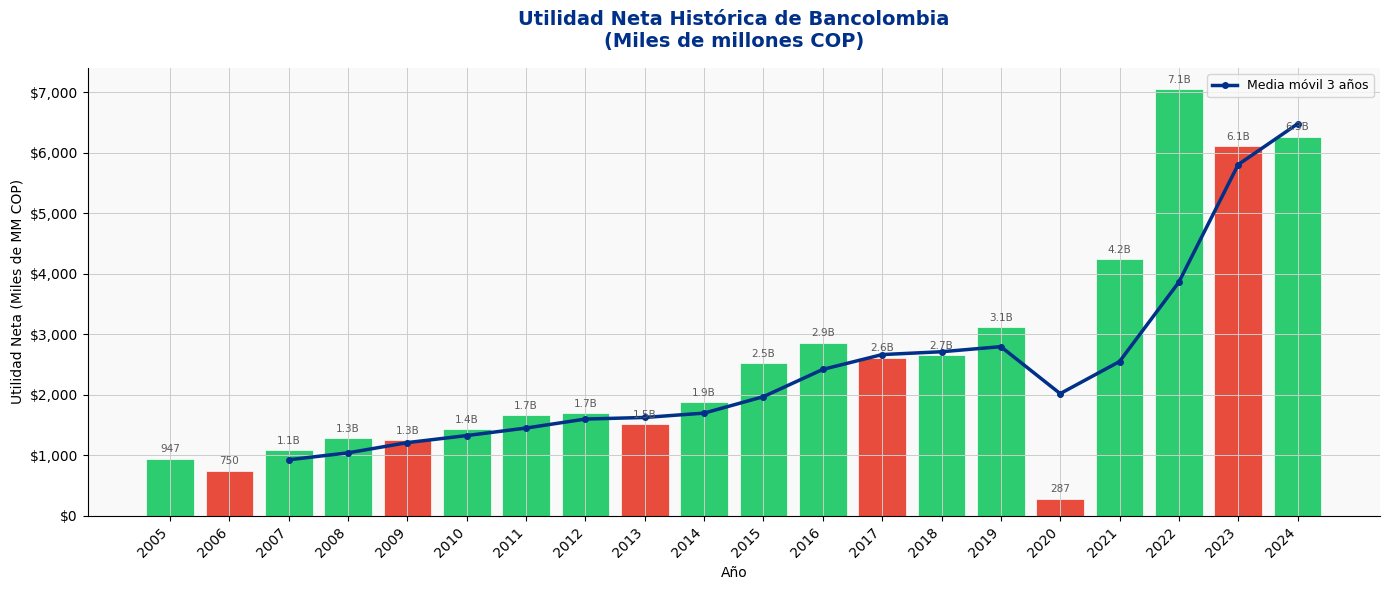

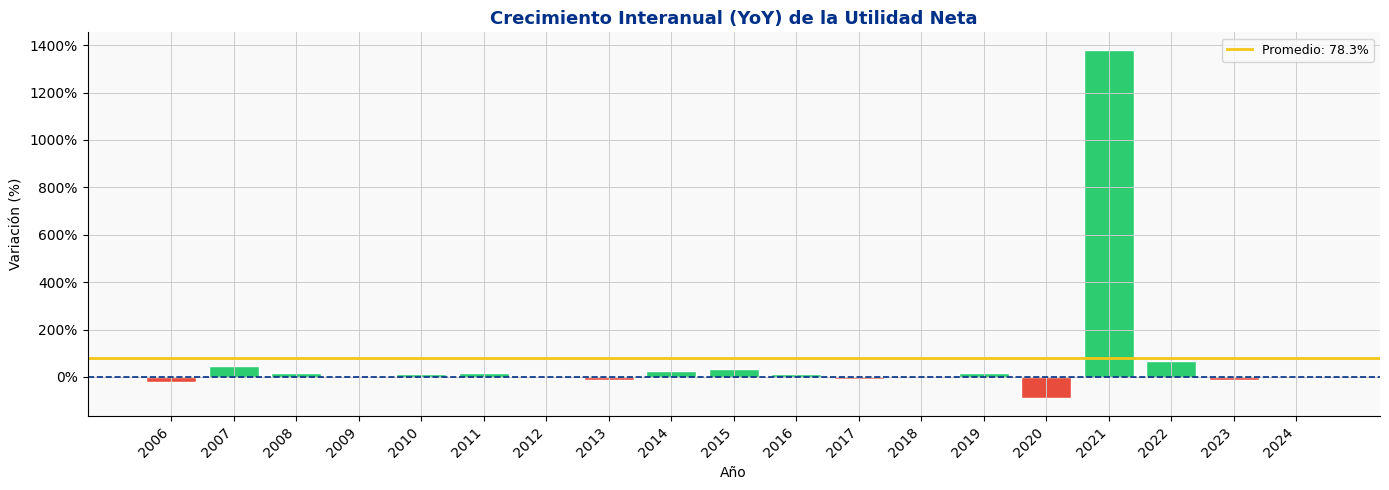

/tmp/ipykernel_1034/74368419.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


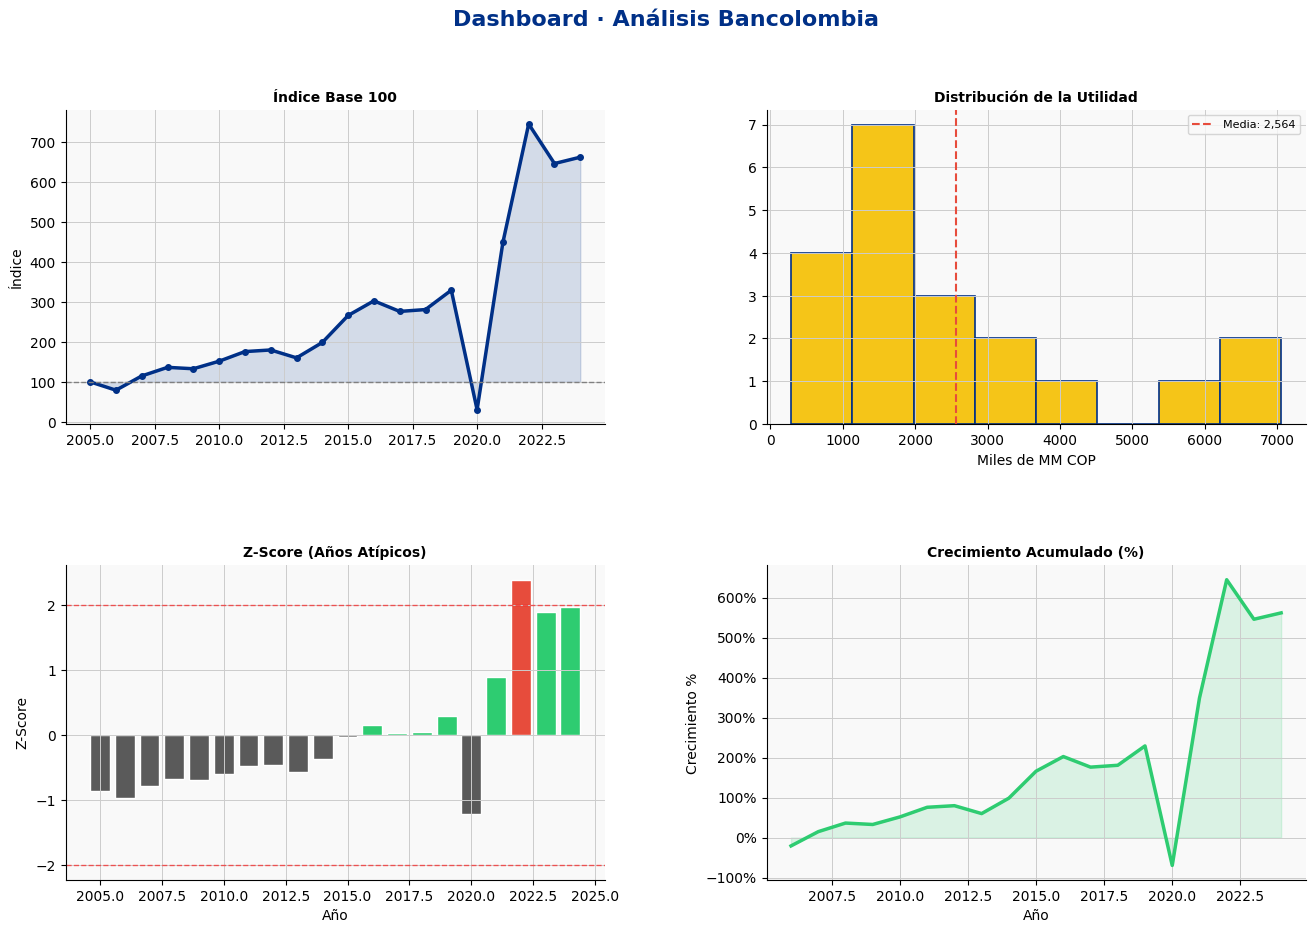

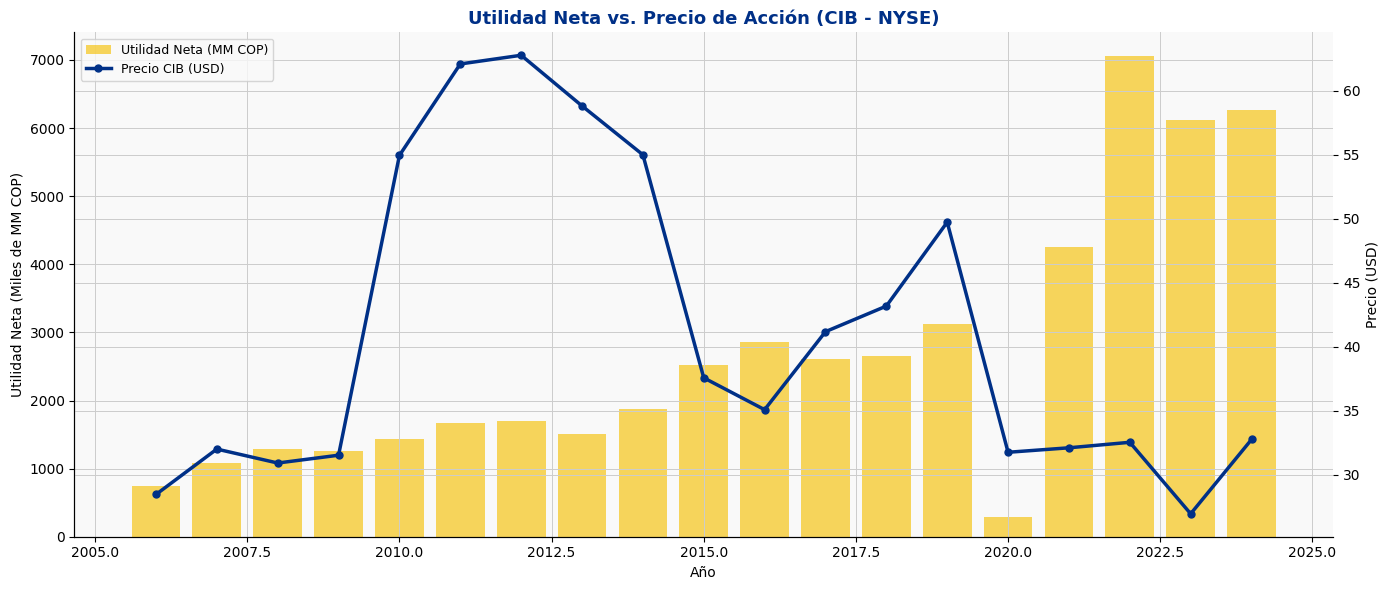

In [ ]:
# ============================================================
# CELDA 11 — Visualizaciones
# ============================================================
viz = FinancialVisualizer(analyzer.df)
viz.plot_all()


In [ ]:
# ============================================================
# CELDA 12 — Reporte final
# ============================================================
reporter = ReportGenerator(analyzer.df, results)
reporter.print_report()

# Descomentar la siguiente línea para descargar el reporte como .txt:
# reporter.save_report("reporte_bancolombia.txt")


  REPORTE DE ANÁLISIS FINANCIERO
  Bancolombia S.A. – Utilidad Neta Histórica
  Generado: 2026-04-24 06:29

  Período:  2005 – 2024  (20 años)

  MÉTRICAS CLAVE
  ├─ CAGR:                10.46%
  ├─ Crecimiento total:   561.9%
  ├─ Promedio anual:  COP      2,563.8 MM
  ├─ Mediana:         COP      1,791.0 MM
  └─ Desv. estándar:  COP      1,880.7 MM

  Mejor año: 2022  → COP    7,053.0 MM
  Peor año:  2020  → COP      287.0 MM

  Años con caída: 2006, 2009, 2013, 2017, 2020, 2023

  TABLA HISTÓRICA
  --------------------------------------------------------
     AÑO   UTILIDAD (MM)    CREC. YOY    Z-SCORE
  --------------------------------------------------------
    2005           946.9         N/A     -0.860
    2006           749.5      -20.9%     -0.965
    2007         1,086.9      +45.0%     -0.785
    2008         1,290.6      +18.7%     -0.677
    2009         1,257.0       -2.6%     -0.695
    2010         1,436.0      +14.2%     -0.600
    2011         1,664.0      +15.9%    